This notebooks evaluates our novel heuristic alpha computation approach based on the dataset metadata

For convinience the code is given below:

In [2]:
def compute_alpha_from_metadata(num_docs,num_queries,num_qrels,rel_counts):
    avg_rels = num_qrels / max(1,num_queries)
    doc_factor = np.clip(np.log10(num_docs)/6,0,1)
    query_factor = np.clip(num_queries/10000,0,1)
    alpha_bm25_bias = 1.0 - 0.5*query_factor - 0.3*doc_factor
    alpha_dense_bias = 1.0 - np.clip(avg_rels/100,0,1)
    alpha = np.clip(0.5*alpha_bm25_bias + 0.5*alpha_dense_bias,0.2,0.8)
    return round(alpha,2)


def get_dataset_metadata(dataset):
    num_docs = sum(1 for _ in dataset.docs_iter())
    num_queries = sum(1 for _ in dataset.queries_iter())
    rel_counts = Counter()
    num_qrels=0
    for r in dataset.qrels_iter():
        num_qrels+=1
        rel_counts[int(r.relevance)]+=1
    return num_docs,num_queries,num_qrels,dict(rel_counts)

### 🧠 Heuristic α Computation — Intuition

The goal of the heuristic α is to **automatically balance** the contribution of sparse (BM25) and dense (semantic) retrievers based on dataset characteristics — without relying on labeled relevance data.

* **Number of Documents (`num_docs`)** →
  Larger corpora tend to have more diverse language and paraphrasing, where **dense models** are more effective.
  Hence, as `num_docs` increases, we slightly **reduce α** (giving less weight to BM25).

* **Number of Queries (`num_queries`)** →
  When a dataset has very few queries, dense models might not generalize well, so we **increase α** to rely more on the lexical BM25 scores.

* **Average Relevance Density (`avg_rels = num_qrels / num_queries`)** →
  If each query has many relevant documents, semantic similarity becomes more important, so we **lower α** to give more weight to dense retrieval.
  When relevance is sparse, we **raise α**, since BM25 excels at pinpointing a few exact matches.

Overall, this heuristic dynamically produces an α value between **0.2 and 0.8**,
where **higher α → more BM25 influence**, and **lower α → more dense influence**,
adapting the hybrid fusion to each dataset’s size and relevance structure.


# Analyzation

In [3]:
# ======================================================
# 📘 Hybrid Retriever Evaluation with Multiple Alphas (UPDATED for Recall@10 + MAP@100)
# ======================================================
import ir_datasets, os, math, numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import defaultdict, Counter

# -------------------------------
# CONFIG
# -------------------------------
DATASETS = [
    "beir/trec-covid","beir/arguana","beir/scifact/test","beir/scifact/train","beir/scidocs",
    "beir/nfcorpus/train","beir/nfcorpus/test","beir/nfcorpus/dev","beir/fiqa/train",
    "beir/fiqa/test","beir/fiqa/dev","beir/cqadupstack/android","beir/cqadupstack/english",
    "beir/cqadupstack/gaming","beir/cqadupstack/gis","beir/cqadupstack/mathematica",
    "beir/cqadupstack/physics","beir/cqadupstack/programmers","beir/cqadupstack/stats",
    "beir/cqadupstack/tex","beir/cqadupstack/unix","beir/cqadupstack/webmasters",
    "beir/cqadupstack/wordpress"
]

RUNS_DIR = "./runs"
TOP_K = 100

# -------------------------------
# METRICS (UPDATED)
# -------------------------------
def ndcg_at_k(run, qrels, k=10):
    def dcg(rels): return sum(rel / math.log2(i + 2) for i, rel in enumerate(rels))
    vals = []
    for qid, ranked in run.items():
        rels=[1 if qrels.get(qid,{}).get(doc,0)>0 else 0 for doc,_ in ranked[:k]]
        idcg = dcg(sorted(rels, reverse=True))
        vals.append((dcg(rels)/idcg) if idcg > 0 else 0.0)
    return float(np.mean(vals)) if vals else 0.0

def mrr_at_k(run,qrels,k=10):
    vals=[]
    for qid, ranked in run.items():
        rr=0
        for i,(doc,_) in enumerate(ranked[:k],1):
            if qrels.get(qid,{}).get(doc,0)>0:
                rr=1/i;break
        vals.append(rr)
    return float(np.mean(vals))

def precision_at_k(run,qrels,k=10):
    vals=[]
    for qid, ranked in run.items():
        rels=[1 if qrels.get(qid,{}).get(doc,0)>0 else 0 for doc,_ in ranked[:k]]
        vals.append(sum(rels)/k)
    return float(np.mean(vals))

def recall_at_k(run,qrels,k=10):     # UPDATED
    vals=[]
    for qid, ranked in run.items():
        rels=qrels.get(qid,{})
        total=sum(1 for _ in rels.values() if _>0)
        if total==0: continue
        hits=sum(1 if rels.get(doc,0)>0 else 0 for doc,_ in ranked[:k])
        vals.append(hits/total)
    return float(np.mean(vals))

def map_at_k(run,qrels,k=100):       # UPDATED
    vals=[]
    for qid, ranked in run.items():
        rels=qrels.get(qid,{})
        hits=0; AP=0
        for i,(doc,_) in enumerate(ranked[:k],1):
            if rels.get(doc,0)>0:
                hits+=1
                AP += hits/i
        if hits>0:
            vals.append(AP/hits)
    return float(np.mean(vals))

# -------------------------------
# TREC Reader
# -------------------------------
def read_trec(path):
    per_q=defaultdict(list)
    with open(path,"r",encoding="utf-8") as f:
        for line in f:
            p=line.split()
            if len(p)<6: continue
            qid,_,doc,_,score,_=p[:6]
            per_q[qid].append((doc,float(score)))
    for qid in per_q:
        per_q[qid].sort(key=lambda x:x[1],reverse=True)
    return per_q

# -------------------------------
# Normalizations (unchanged)
# -------------------------------
def minmax_norm(scores):
    if not scores: return {}
    vals=np.array([s for _,s in scores])
    lo,hi=vals.min(),vals.max()
    if hi<=lo: return {d:0.0 for d,_ in scores}
    return {d:(s-lo)/(hi-lo) for d,s in scores}

def zscore_norm(scores):
    if not scores: return {}
    vals=np.array([s for _,s in scores])
    mu,sigma=vals.mean(),vals.std()+1e-9
    return {d:(s-mu)/sigma for d,s in scores}

def rank_norm(scores):
    n=len(scores)
    sorted_scores=sorted(scores,key=lambda x:x[1],reverse=True)
    return {doc:(n-r)/(n-1) for r,(doc,_) in enumerate(sorted_scores,1)}

# -------------------------------
# Fusion (unchanged)
# -------------------------------
def fuse_per_query(qid,bm25,dense,norm,alpha,topk=TOP_K):
    b,d=bm25.get(qid,[]),dense.get(qid,[])
    if norm=="minmax": bn,dn=minmax_norm(b),minmax_norm(d)
    elif norm=="zscore": bn,dn=zscore_norm(b),zscore_norm(d)
    else: bn,dn=rank_norm(b),rank_norm(d)
    cand=set([doc for doc,_ in b])|set([doc for doc,_ in d])
    fused=[(doc,alpha*bn.get(doc,0)+(1-alpha)*dn.get(doc,0)) for doc in cand]
    fused.sort(key=lambda x:x[1],reverse=True)
    return fused[:topk]

def build_hybrid_run(bm25,dense,norm,alpha):
    run=defaultdict(list)
    for qid in sorted(set(list(bm25.keys())+list(dense.keys()))):
        run[qid]=fuse_per_query(qid,bm25,dense,norm,alpha)
    return run

# -------------------------------
# Heuristic Alpha (unchanged)
# -------------------------------
def compute_alpha_from_metadata(num_docs,num_queries,num_qrels,rel_counts):
    avg_rels=num_qrels/max(1,num_queries)
    doc_factor=np.clip(np.log10(num_docs)/6,0,1)
    query_factor=np.clip(num_queries/10000,0,1)
    alpha_bm25_bias=1.0-0.5*query_factor-0.3*doc_factor
    alpha_dense_bias=1.0-np.clip(avg_rels/100,0,1)
    alpha=np.clip(0.5*alpha_bm25_bias+0.5*alpha_dense_bias,0.2,0.8)
    return round(alpha,2)

def get_dataset_metadata(dataset):
    num_docs=sum(1 for _ in dataset.docs_iter())
    num_queries=sum(1 for _ in dataset.queries_iter())
    rel_counts=Counter(); num_qrels=0
    for r in dataset.qrels_iter():
        num_qrels+=1
        rel_counts[int(r.relevance)]+=1
    return num_docs,num_queries,num_qrels,dict(rel_counts)

# -------------------------------
# MAIN LOOP (UPDATED METRICS)
# -------------------------------
metrics_funcs={
    "nDCG@10":lambda r,q:ndcg_at_k(r,q),
    "MRR@10":lambda r,q:mrr_at_k(r,q),
    "Precision@10":lambda r,q:precision_at_k(r,q),
    "Recall@10":lambda r,q:recall_at_k(r,q,10),   # UPDATED
    "MAP@100":lambda r,q:map_at_k(r,q,100)        # UPDATED
}

results=[]
fixed_alphas=[0.4,0.5,0.6]

for DATASET_NAME in DATASETS:
    print(f"\n🔹 Evaluating {DATASET_NAME}")
    dataset=ir_datasets.load(DATASET_NAME)

    qrels={}
    for r in dataset.qrels_iter():
        qrels.setdefault(str(r.query_id),{})[str(r.doc_id)] = int(r.relevance)

    num_docs,num_queries,num_qrels,rel_counts=get_dataset_metadata(dataset)
    heur_alpha=compute_alpha_from_metadata(num_docs,num_queries,num_qrels,rel_counts)

    bm25_path=os.path.join(RUNS_DIR,f"run_bm25_{DATASET_NAME.replace('/','_')}.trec")
    dense_path=os.path.join(RUNS_DIR,f"run_dense_{DATASET_NAME.replace('/','_')}.trec")
    if not (os.path.exists(bm25_path) and os.path.exists(dense_path)):
        print("⚠ Missing run files, skipping.")
        continue

    bm25 = read_trec(bm25_path)
    dense = read_trec(dense_path)

    print(f"Heuristic α = {heur_alpha}")

    for norm in ["minmax","zscore","rank"]:
        for alpha in fixed_alphas + [heur_alpha]:
            run = build_hybrid_run(bm25,dense,norm,alpha)
            scores = {m:func(run,qrels) for m,func in metrics_funcs.items()}

            print(f"{norm:<8} α={alpha:.2f} | "
                  f"nDCG={scores['nDCG@10']:.4f}, "
                  f"MRR={scores['MRR@10']:.4f}, "
                  f"P@10={scores['Precision@10']:.4f}, "
                  f"R@10={scores['Recall@10']:.4f}, "
                  f"MAP@100={scores['MAP@100']:.4f}")

            results.append({
                "dataset":DATASET_NAME,
                "norm":norm,
                "alpha":alpha,
                **scores
            })

df = pd.DataFrame(results)
df.head()



🔹 Evaluating beir/trec-covid
Heuristic α = 0.37
minmax   α=0.40 | nDCG=0.9058, MRR=0.8791, P@10=0.7765, R@10=0.0156, MAP@100=0.7135
minmax   α=0.50 | nDCG=0.9466, MRR=0.9706, P@10=0.7647, R@10=0.0154, MAP@100=0.7186
minmax   α=0.60 | nDCG=0.9171, MRR=0.9020, P@10=0.7529, R@10=0.0150, MAP@100=0.7157
minmax   α=0.37 | nDCG=0.8880, MRR=0.8725, P@10=0.7765, R@10=0.0154, MAP@100=0.7085
zscore   α=0.40 | nDCG=0.8994, MRR=0.8515, P@10=0.7471, R@10=0.0151, MAP@100=0.6909
zscore   α=0.50 | nDCG=0.9164, MRR=0.9118, P@10=0.7588, R@10=0.0152, MAP@100=0.6936
zscore   α=0.60 | nDCG=0.8833, MRR=0.8725, P@10=0.7588, R@10=0.0152, MAP@100=0.6904
zscore   α=0.37 | nDCG=0.8949, MRR=0.8490, P@10=0.7471, R@10=0.0151, MAP@100=0.6891
rank     α=0.40 | nDCG=0.9570, MRR=0.9314, P@10=0.8118, R@10=0.0166, MAP@100=0.7160
rank     α=0.50 | nDCG=0.9625, MRR=0.9706, P@10=0.8118, R@10=0.0166, MAP@100=0.7424
rank     α=0.60 | nDCG=0.9347, MRR=0.9412, P@10=0.8176, R@10=0.0170, MAP@100=0.7492
rank     α=0.37 | nDCG=0.95

,dataset,norm,alpha,nDCG@10,MRR@10,Precision@10,Recall@10,MAP@100
0,beir/trec-covid,minmax,0.40,0.905807,0.879085,0.776471,0.015586,0.713520
1,beir/trec-covid,minmax,0.50,0.946639,0.970588,0.764706,0.015353,0.718636
2,beir/trec-covid,minmax,0.60,0.917143,0.901961,0.752941,0.014987,0.715656
3,beir/trec-covid,minmax,0.37,0.887986,0.872549,0.776471,0.015397,0.708464
4,beir/trec-covid,zscore,0.40,0.899373,0.851541,0.747059,0.015123,0.690890


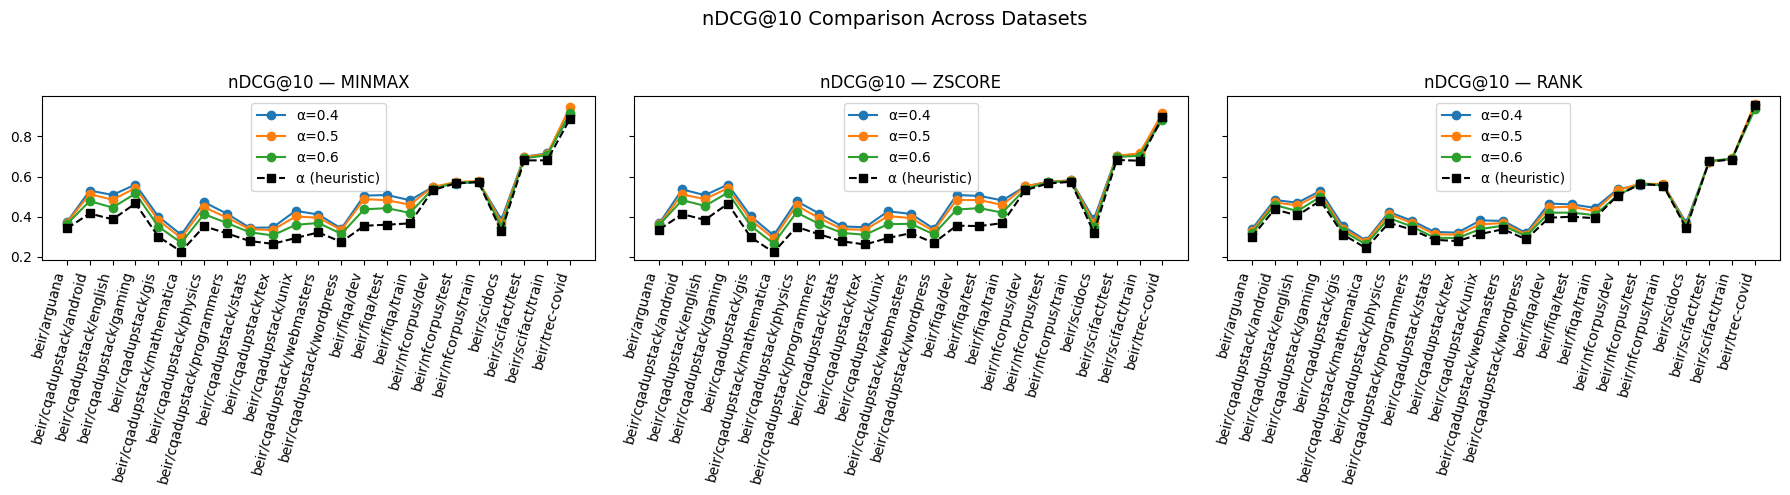

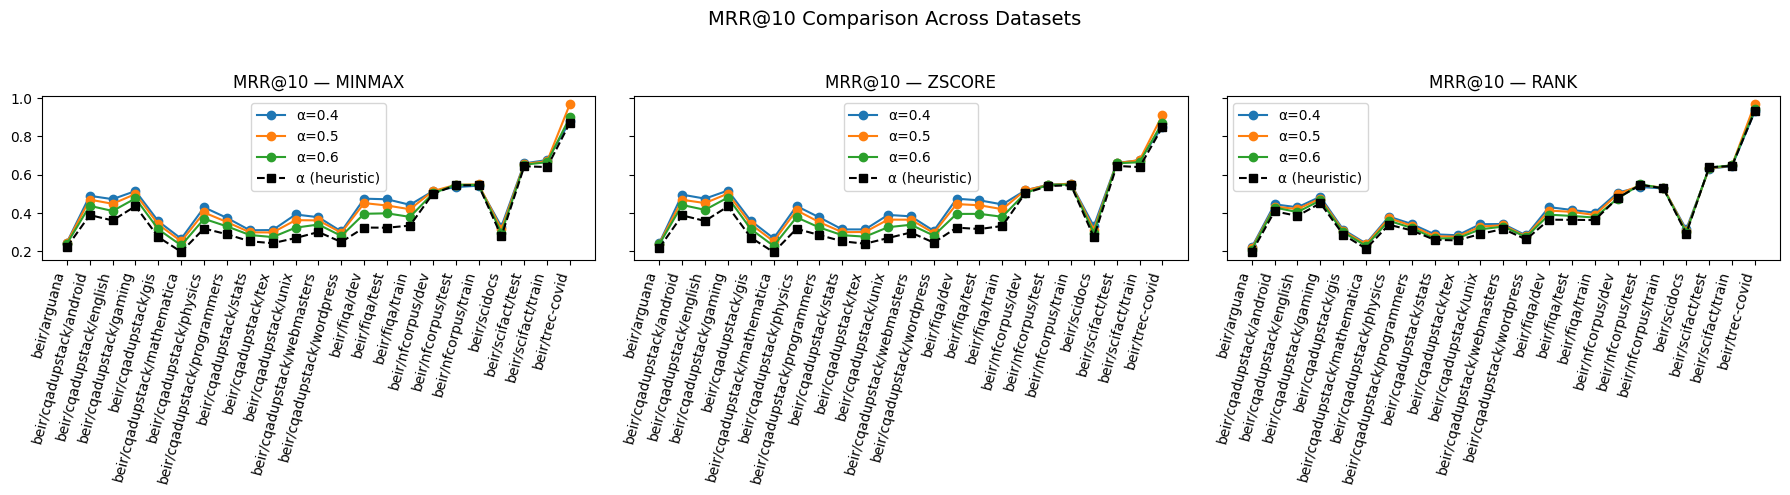

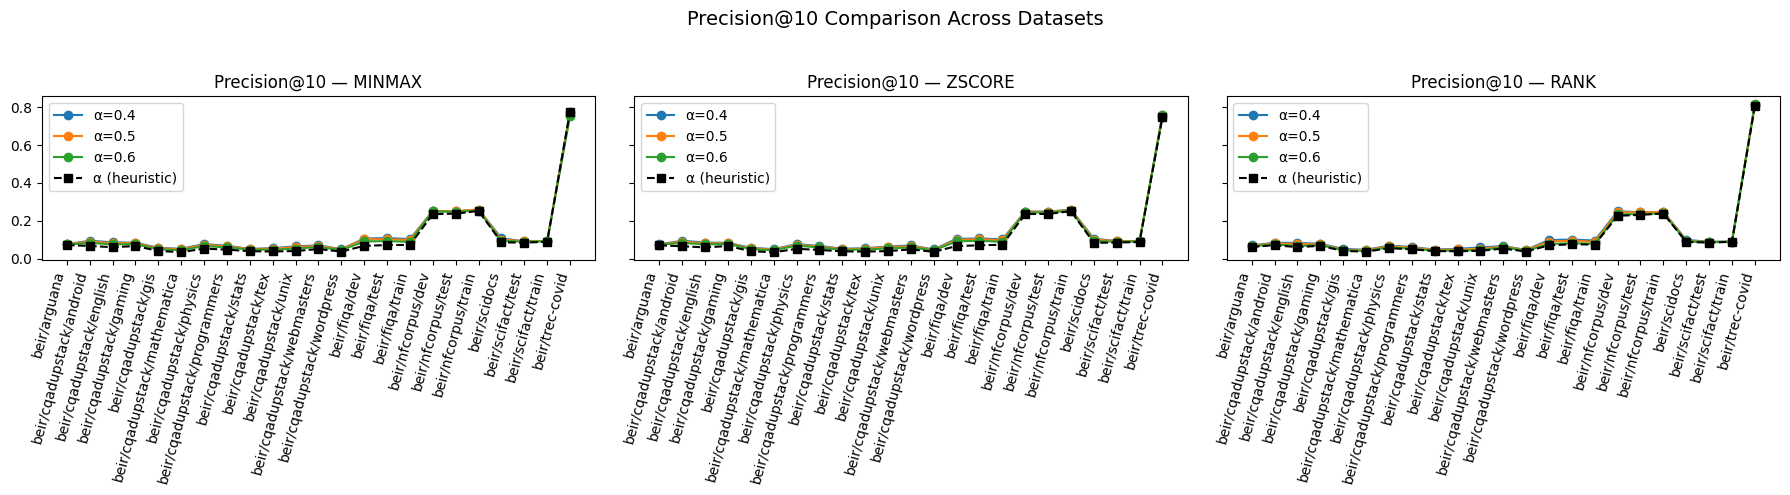

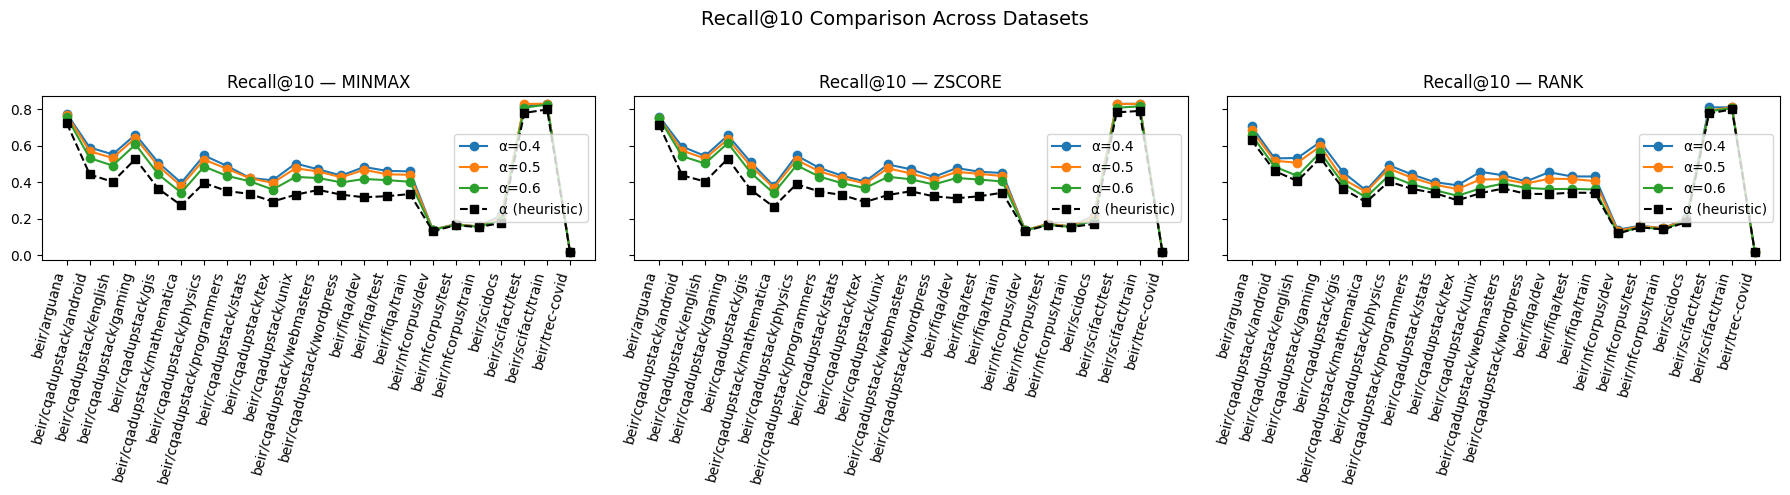

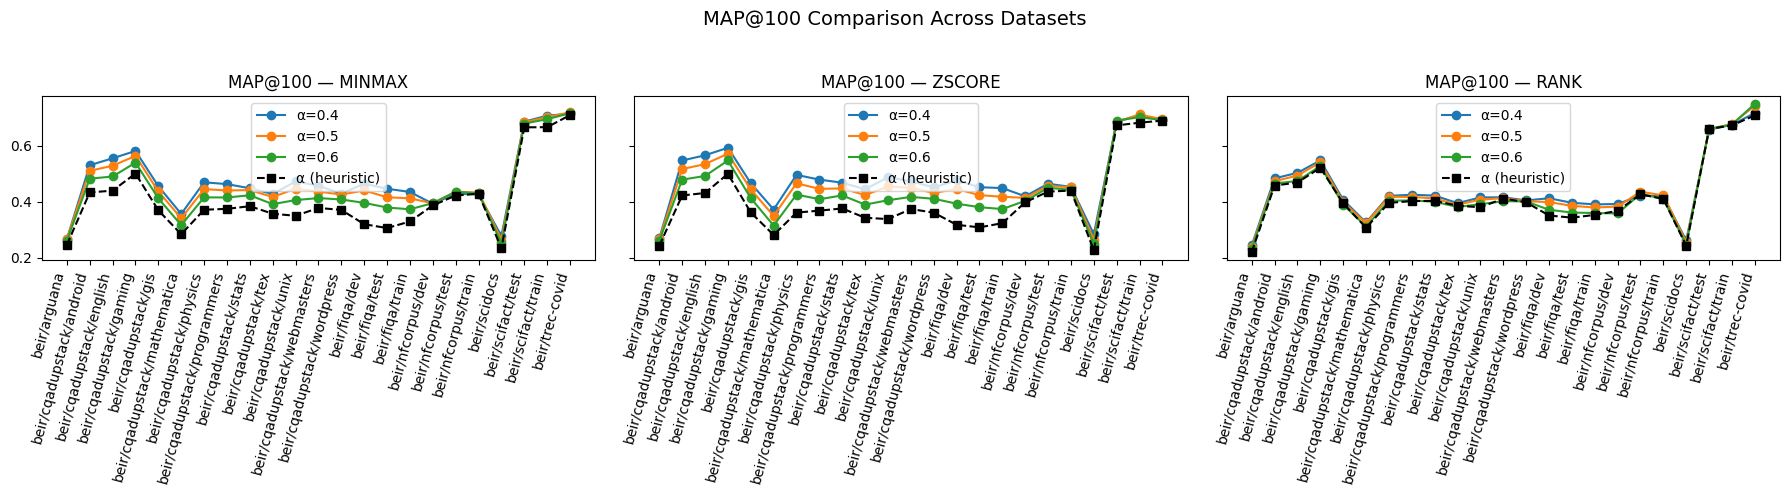

In [4]:
# -------------------------------
# FIXED + HEURISTIC PLOTTING (UPDATED)
# -------------------------------
metrics_to_plot = ["nDCG@10","MRR@10","Precision@10","Recall@10","MAP@100"]
norms = ["minmax","zscore","rank"]
fixed_alphas = [0.4, 0.5, 0.6]

for metric in metrics_to_plot:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for i, norm in enumerate(norms):
        subset = df[df["norm"] == norm].copy()
        datasets_sorted = sorted(subset["dataset"].unique())
        x = np.arange(len(datasets_sorted))

        # --- Fixed alphas ---
        for alpha in fixed_alphas:
            data = subset[subset["alpha"] == alpha].set_index("dataset").reindex(datasets_sorted)
            axes[i].plot(x, data[metric], marker="o", label=f"α={alpha:.1f}")

        # --- Heuristic alpha ---
        heur_subset = subset[~subset["alpha"].isin(fixed_alphas)]
        if not heur_subset.empty:
            heur_data = heur_subset.groupby("dataset")[metric].mean().reindex(datasets_sorted)
            axes[i].plot(x, heur_data, marker="s", linestyle="--", color="black", label="α (heuristic)")

        axes[i].set_title(f"{metric} — {norm.upper()}")
        axes[i].set_xticks(x)
        axes[i].set_xticklabels(datasets_sorted, rotation=75, ha="right")
        axes[i].legend()

    plt.suptitle(f"{metric} Comparison Across Datasets", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()



🔹 Normalization: MINMAX

📊 Metric: nDCG@10
rank              1     2     3     4
alpha_label                          
α (heuristic)   0.0   0.0   4.3  95.7
α=0.4          82.6   4.3   8.7   4.3
α=0.5          17.4  82.6   0.0   0.0
α=0.6           0.0  13.0  87.0   0.0


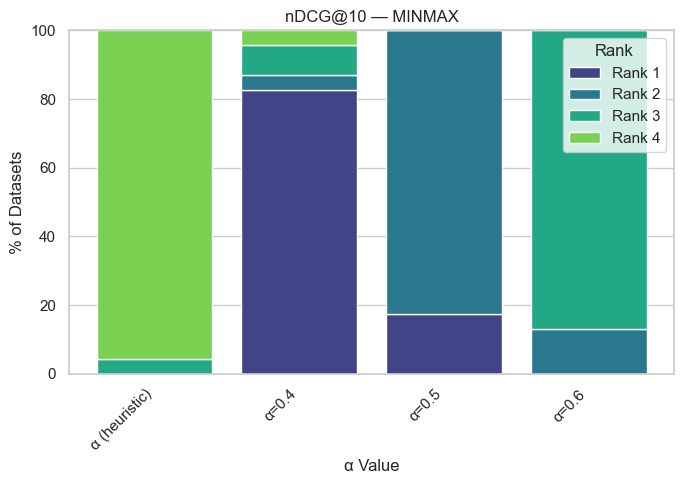


📊 Metric: MRR@10
rank              1     2     3     4
alpha_label                          
α (heuristic)   0.0   0.0   8.7  91.3
α=0.4          82.6   4.3   4.3   8.7
α=0.5          13.0  87.0   0.0   0.0
α=0.6           4.3   8.7  87.0   0.0


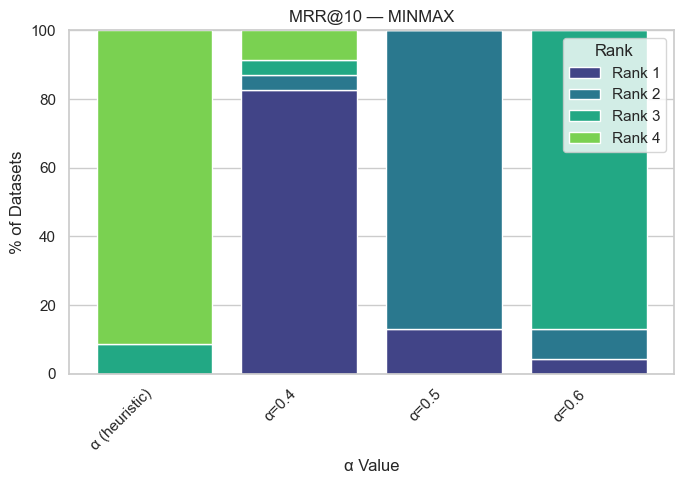


📊 Metric: Precision@10
rank              1     2     3     4
alpha_label                          
α (heuristic)   0.0   4.3   0.0  95.7
α=0.4          87.0  13.0   0.0   0.0
α=0.5          17.4  78.3   4.3   0.0
α=0.6           0.0   0.0  95.7   4.3


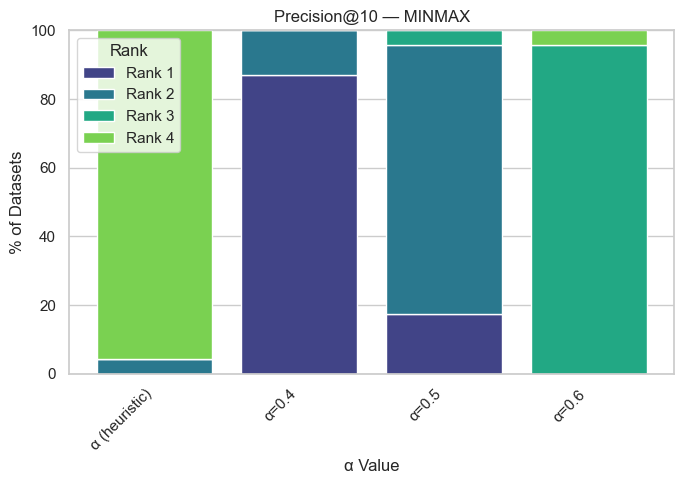


📊 Metric: Recall@10
rank              1     2     3     4
alpha_label                          
α (heuristic)   0.0   4.3   0.0  95.7
α=0.4          87.0  13.0   0.0   0.0
α=0.5          13.0  82.6   4.3   0.0
α=0.6           0.0   0.0  95.7   4.3


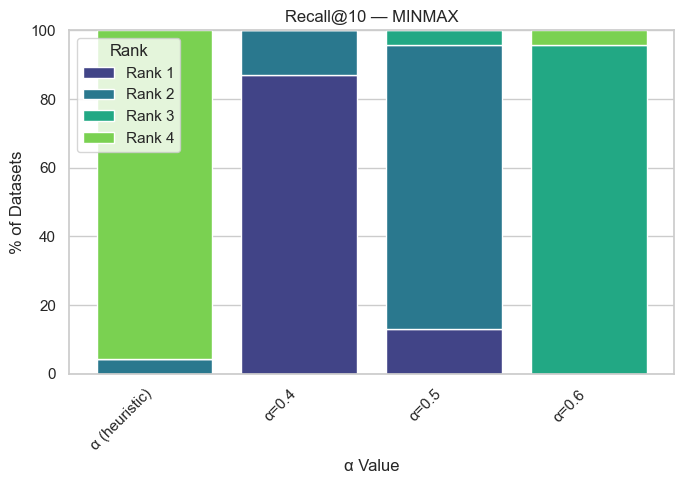


📊 Metric: MAP@100
rank              1     2     3     4
alpha_label                          
α (heuristic)   0.0   0.0   4.3  95.7
α=0.4          82.6   0.0  13.0   4.3
α=0.5          13.0  87.0   0.0   0.0
α=0.6           4.3  13.0  82.6   0.0


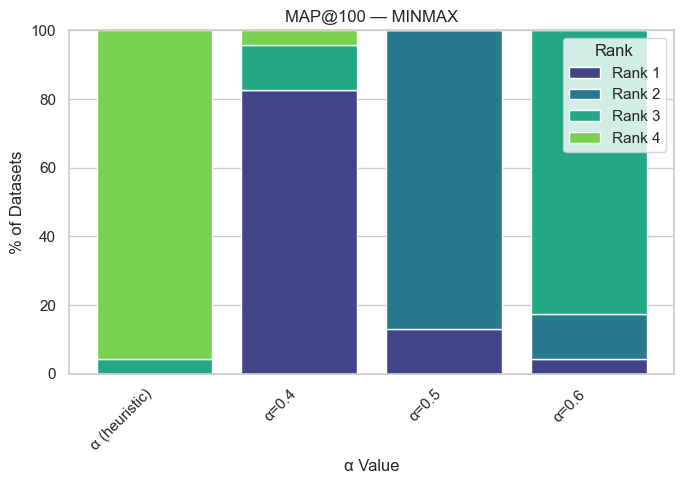


🔹 Normalization: ZSCORE

📊 Metric: nDCG@10
rank              1     2     3     4
alpha_label                          
α (heuristic)   0.0   0.0   4.3  95.7
α=0.4          78.3  21.7   0.0   0.0
α=0.5          21.7  78.3   0.0   0.0
α=0.6           0.0   0.0  95.7   4.3


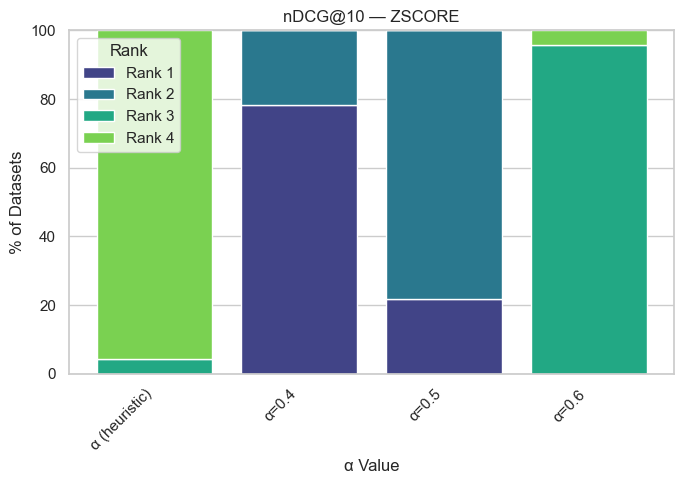


📊 Metric: MRR@10
rank              1     2     3      4
alpha_label                           
α (heuristic)   0.0   0.0   0.0  100.0
α=0.4          82.6  13.0   4.3    0.0
α=0.5          17.4  78.3   4.3    0.0
α=0.6           0.0   8.7  91.3    0.0


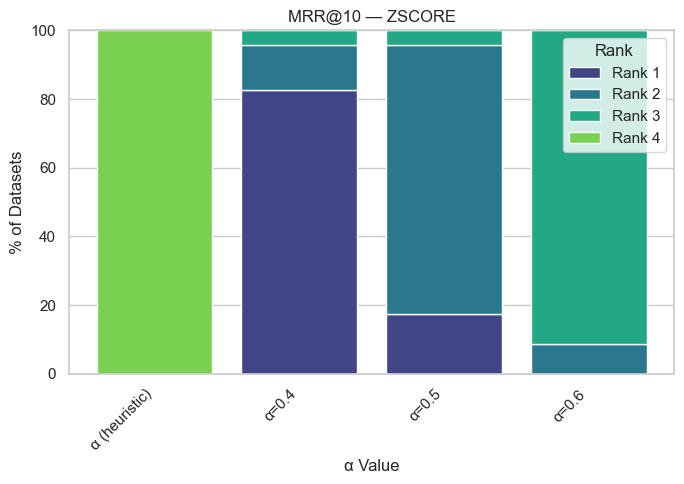


📊 Metric: Precision@10
rank              1     2     3     4
alpha_label                          
α (heuristic)   0.0   0.0   4.3  95.7
α=0.4          95.7   0.0   4.3   0.0
α=0.5           8.7  91.3   0.0   0.0
α=0.6           4.3   0.0  95.7   0.0


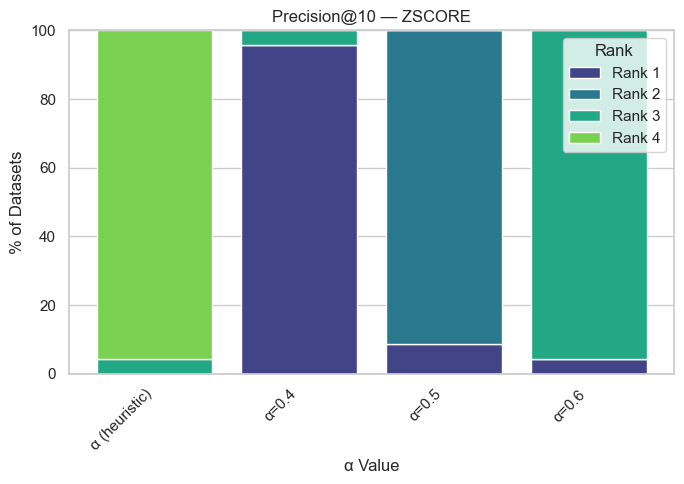


📊 Metric: Recall@10
rank              1     2     3      4
alpha_label                           
α (heuristic)   0.0   0.0   0.0  100.0
α=0.4          91.3   4.3   4.3    0.0
α=0.5          13.0  87.0   0.0    0.0
α=0.6           0.0   4.3  95.7    0.0


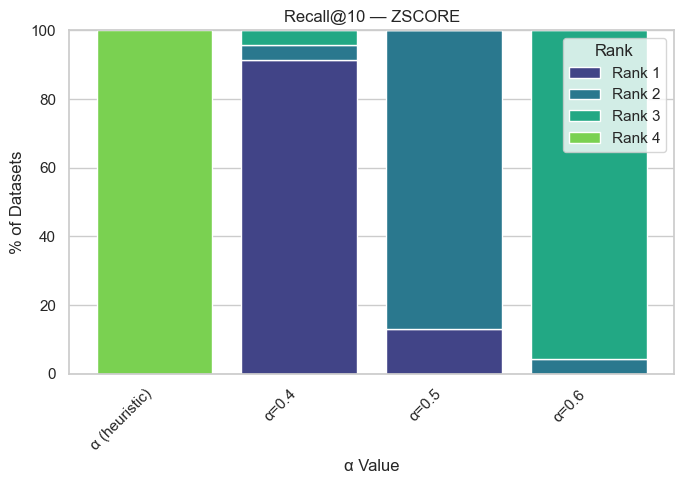


📊 Metric: MAP@100
rank              1     2     3      4
alpha_label                           
α (heuristic)   0.0   0.0   0.0  100.0
α=0.4          87.0   8.7   4.3    0.0
α=0.5           8.7  91.3   0.0    0.0
α=0.6           4.3   0.0  95.7    0.0


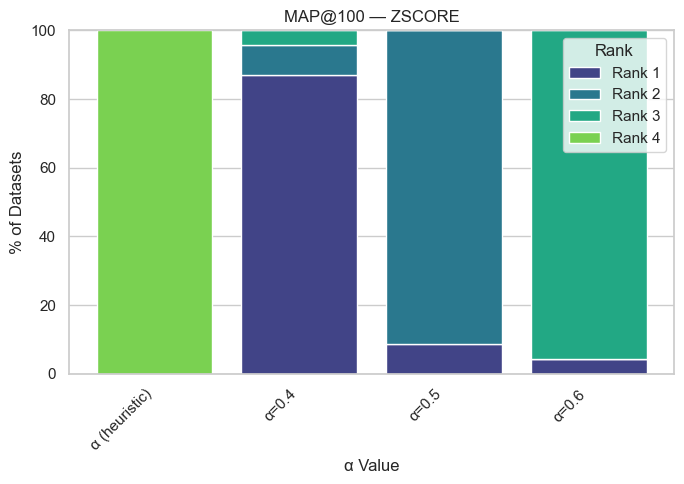


🔹 Normalization: RANK

📊 Metric: nDCG@10
rank              1     2     3     4
alpha_label                          
α (heuristic)   0.0   4.3   8.7  87.0
α=0.4          78.3   8.7   8.7   4.3
α=0.5          13.0  82.6   0.0   4.3
α=0.6           8.7   4.3  82.6   4.3


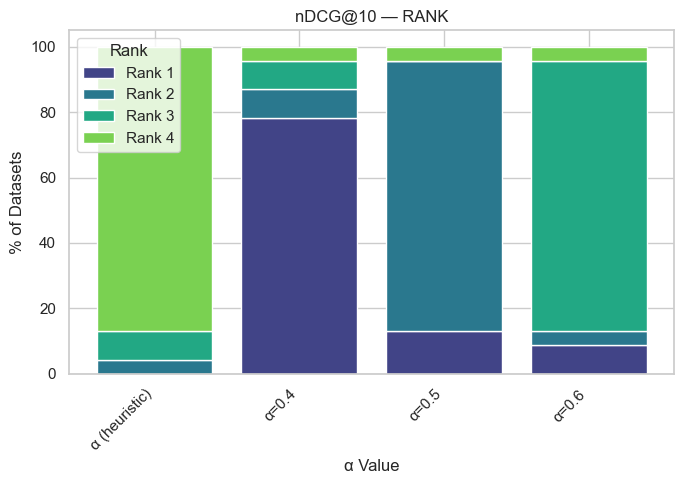


📊 Metric: MRR@10
rank              1     2     3     4
alpha_label                          
α (heuristic)   4.3   4.3  17.4  73.9
α=0.4          78.3   0.0   4.3  17.4
α=0.5           8.7  82.6   8.7   0.0
α=0.6           8.7  13.0  73.9   4.3


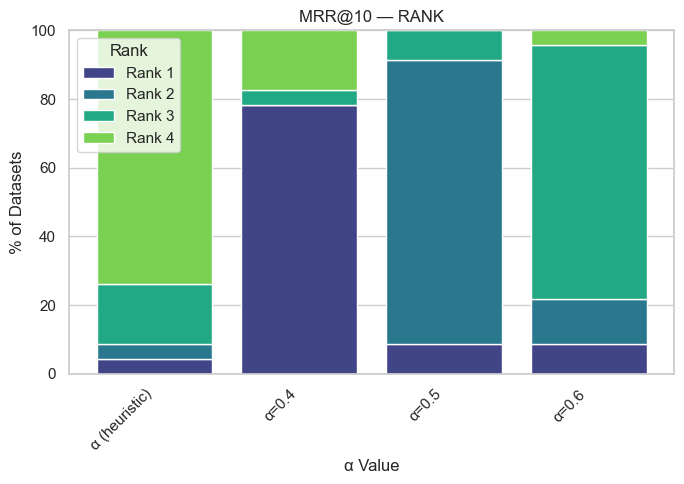


📊 Metric: Precision@10
rank              1     2     3      4
alpha_label                           
α (heuristic)   0.0   0.0   0.0  100.0
α=0.4          95.7   4.3   0.0    0.0
α=0.5           4.3  95.7   0.0    0.0
α=0.6           4.3   0.0  95.7    0.0


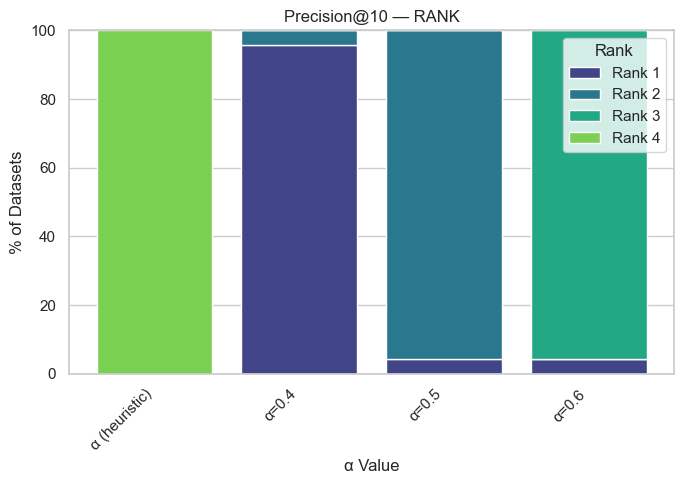


📊 Metric: Recall@10
rank              1     2     3     4
alpha_label                          
α (heuristic)   0.0   0.0   4.3  95.7
α=0.4          87.0   8.7   4.3   0.0
α=0.5           8.7  91.3   0.0   0.0
α=0.6           4.3   0.0  91.3   4.3


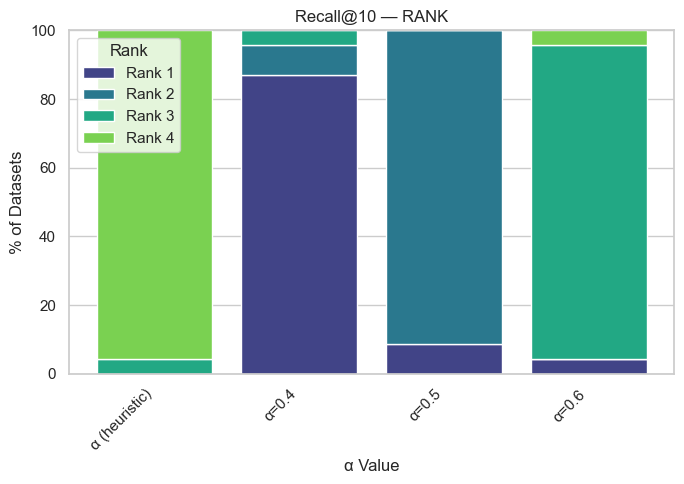


📊 Metric: MAP@100
rank              1     2     3     4
alpha_label                          
α (heuristic)   0.0   4.3  30.4  65.2
α=0.4          78.3   4.3   8.7   8.7
α=0.5          13.0  82.6   4.3   0.0
α=0.6           8.7   8.7  56.5  26.1


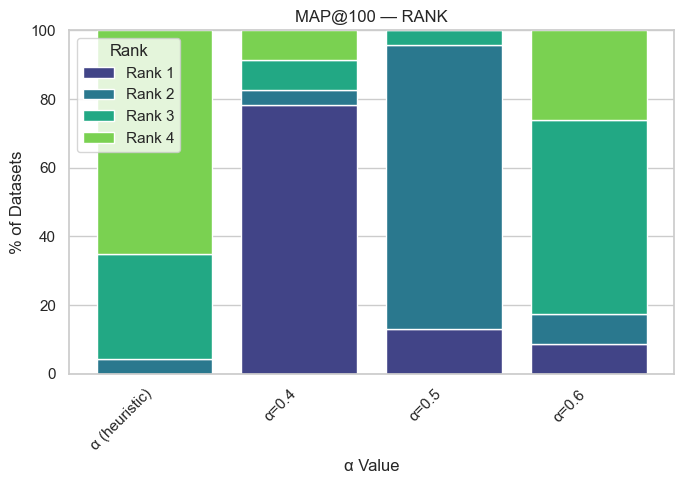

In [5]:
# ======================================================
# 📊 Hybrid α Ranking Statistics + Visualization (UPDATED)
# ======================================================
import matplotlib.pyplot as plt
import seaborn as sns

metrics_to_plot = ["nDCG@10","MRR@10","Precision@10","Recall@10","MAP@100"]
norms = ["minmax","zscore","rank"]
fixed_alphas = [0.4, 0.5, 0.6]

df["is_heuristic"] = ~df["alpha"].isin(fixed_alphas)
df["alpha_label"] = df.apply(lambda x: "α (heuristic)" if x["is_heuristic"] else f"α={x['alpha']:.1f}", axis=1)

summary_rows = []

# Compute rankings
for norm in norms:
    for metric in metrics_to_plot:
        subset = df[df["norm"] == norm]
        for dataset, group in subset.groupby("dataset"):
            g = group.copy()
            g["rank"] = g[metric].rank(ascending=False, method="min")
            for _, row in g.iterrows():
                summary_rows.append({
                    "norm": norm,
                    "metric": metric,
                    "dataset": dataset,
                    "alpha_label": row["alpha_label"],
                    "rank": int(row["rank"])
                })

rank_df = pd.DataFrame(summary_rows)

rank_summary = (
    rank_df.groupby(["norm", "metric", "alpha_label", "rank"], as_index=False)
    .size()
    .rename(columns={"size":"count"})
)

rank_summary["percentage"] = (
    rank_summary.groupby(["norm", "metric", "alpha_label"])["count"]
    .transform(lambda x: 100 * x / x.sum())
)

# Plot
sns.set(style="whitegrid", font_scale=1.0)
palette = sns.color_palette("viridis", 4)

for norm in norms:
    print(f"\n==============================")
    print(f"🔹 Normalization: {norm.upper()}")
    print(f"==============================")

    for metric in metrics_to_plot:
        print(f"\n📊 Metric: {metric}")
        sub = rank_summary[(rank_summary["norm"] == norm) &
                           (rank_summary["metric"] == metric)]
        pivot = sub.pivot(index="alpha_label", columns="rank", values="percentage").fillna(0)
        pivot = pivot.reindex(columns=sorted(pivot.columns))

        print(pivot.round(1).to_string())

        plt.figure(figsize=(7,5))
        bottom = np.zeros(len(pivot))
        for rank in pivot.columns:
            plt.bar(pivot.index, pivot[rank], bottom=bottom,
                    label=f"Rank {rank}", color=palette[rank-1])
            bottom += pivot[rank].values

        plt.title(f"{metric} — {norm.upper()}")
        plt.ylabel("% of Datasets")
        plt.xlabel("α Value")
        plt.xticks(rotation=45, ha="right")
        plt.legend(title="Rank")
        plt.tight_layout()
        plt.show()
